# Ecommerce_Sales_Data (2024-2025)

## INTRODUCTION
E-commerce is one of the fastest-growing industries in today’s digital world. With millions of online transactions happening every day, e-commerce platforms generate a large amount of data that can be analyzed to understand customer behavior, product trends, and business performance.

This project focuses on analyzing **E-commerce Sales Data for the years 2024–2025**. By studying different factors such as sales, profit, customer details, product categories, and order patterns, the aim is to extract meaningful insights that will support better decision-making.

The Analysis includes:
* Monthly sales trends
* Top-selling products
* Category-wise revenue
* Customer behaviour
* Regional performance

## GOAL
***The goal is to understand how sales changed over time, which products and categories performed best, and how customers behaved 
covering the period of 2024-2025***

## Data Loading and Initial overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Ecommerce_Sales_Data_2024_2025.xlsx")
df.head()
df.columns = df.columns.str.replace('\xa0', ' ', regex=False)

In [7]:
df

,Order ID,Order Date,Customer Name,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,2024-06-25,Nishith Kulkarni,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.0,31237.23,Credit Card
4997,14998,2025-04-15,Dhanush Gara,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162,15,35837.7,7827.50,Debit Card
4998,14999,2024-07-08,Divyansh Malhotra,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568,10,48844.8,6603.86,Credit Card


In [5]:
#initial overview
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   City           5000 non-null   object        
 4   Category       5000 non-null   object        
 5   Sub-Category   5000 non-null   object        
 6   Product Name   5000 non-null   object        
 7   Quantity       5000 non-null   int64         
 8   Unit Price     5000 non-null   int64         
 9   Discount       5000 non-null   int64         
 10  Sales          5000 non-null   float64       
 11  Profit         5000 non-null   float64       
 12  Payment Mode   5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 507.9+ KB


Index(['Order ID', 'Order Date', 'Customer Name', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

##  Data Pre-processing
### • Handling missing values  
### • Removing duplicates  
### • Correcting data types  
### • Creating derived columns

In [4]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.columns.tolist()

['Order ID',
 'Order Date',
 'Customer Name',
 'City',
 'Category',
 'Sub-Category',
 'Product Name',
 'Quantity',
 'Unit Price',
 'Discount',
 'Sales',
 'Profit',
 'Payment Mode']

## Exploratory Data Analysis(EDA)
### 1.Univariate Analysis
### Distribution of numerical columns

In [27]:
# Univariate Analysis – Numerical Columns
df[['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit', 'Total Amount']].describe()

,Quantity,Unit Price,Discount,Sales,Profit,Total Amount
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.992600,39760.904600,10.051000,106733.204870,15941.746982,118634.217800
std,1.413133,22831.783946,7.084662,85108.208202,14897.684916,93792.624893
min,1.000000,222.000000,0.000000,264.100000,19.120000,278.000000
25%,2.000000,20312.250000,5.000000,39766.537500,4892.295000,44950.500000
50%,3.000000,39459.500000,10.000000,83080.325000,11108.525000,94378.000000
75%,4.000000,59721.750000,15.000000,156968.587500,22467.987500,173078.250000
max,5.000000,79998.000000,20.000000,398485.000000,89688.440000,399400.000000


### Histogram for each numerical column

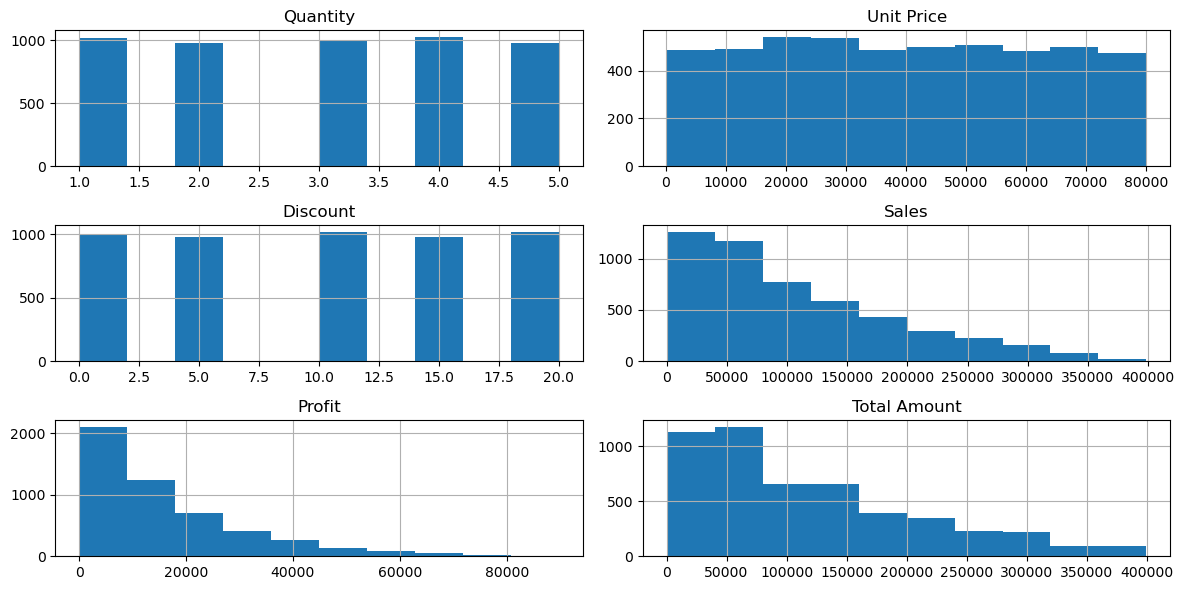

In [30]:
import matplotlib.pyplot as plt

df[['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit', 'Total Amount']].hist(figsize=(12,6))
plt.tight_layout()
plt.show()

### Count plot for categorical columns

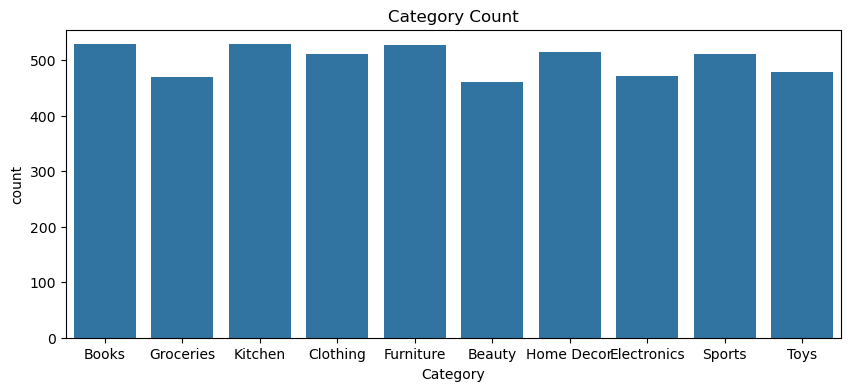

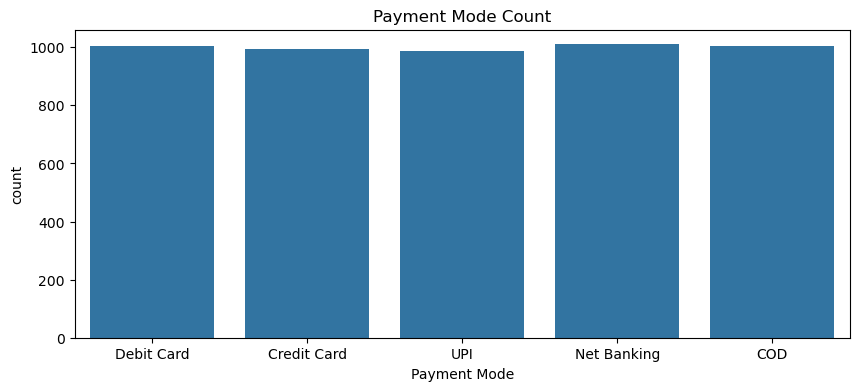

In [36]:
import seaborn as sns

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Category')
plt.title("Category Count")
plt.show()

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Payment Mode')
plt.title("Payment Mode Count")
plt.show()
 

### For categorical columns (Category, City, Payment Mode), we used count plots to observe:
- The most frequent categories
- Distribution of different groups


## 2.Bivariate Analysis
### Relationship between Sales and Profit

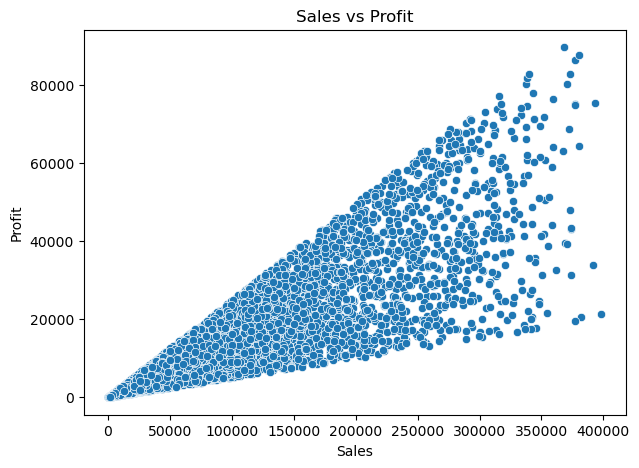

In [37]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Sales', y='Profit')
plt.title("Sales vs Profit")
plt.show()

### Average sales by Category

In [38]:
df.groupby('Category')['Sales'].mean()

Category
Beauty         110442.195000
Books          104039.096591
Clothing       107737.589628
Electronics    111415.008369
Furniture      107489.920114
Groceries      101878.942872
Home Decor     111132.470583
Kitchen        102704.360417
Sports         101897.059198
Toys           109262.272908
Name: Sales, dtype: float64

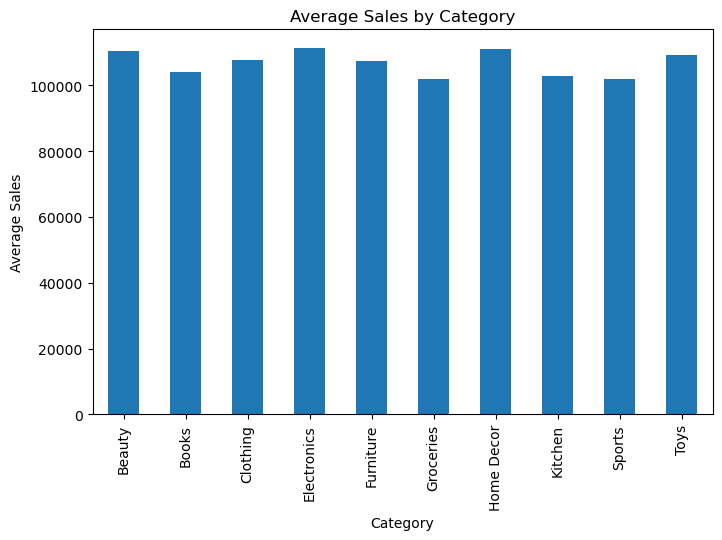

In [39]:
df.groupby('Category')['Sales'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Category")
plt.ylabel("Average Sales")
plt.show()

### In bivariate analysis, we explored relationships between two variables.

Key findings include:
- A scatter plot between Sales and Profit helped identify whether higher sales lead to higher profits.
- Groupby operations revealed how average sales differ across categories.
This analysis helped uncover meaningful relationships that could influence business decisions.

## 3.Multivariate Analysis
### Pivot Table (category+Sub-category with Sales)

In [40]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Sub-Category', aggfunc='sum')
pivot

Sub-Category,Accessories,Action Figure,Bed,Biography,Board Game,Cabinet,Camera,Chair,Clock,Comics,...,Spices,Sugar,Table,Tennis Racket,Textbook,Vase,Wall Art,Wheat,Women's Wear,Yoga Mat
Category,,,,,,,,,,,,,,,,,,,,,
Beauty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Books,NaN,NaN,NaN,9990434.2,NaN,NaN,NaN,NaN,NaN,10061464.85,...,NaN,NaN,NaN,NaN,10285597.4,NaN,NaN,NaN,NaN,NaN
Clothing,11719871.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12646602.9,NaN
Electronics,NaN,NaN,NaN,NaN,NaN,NaN,10547720.1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furniture,NaN,NaN,12211588.6,NaN,NaN,10367085.35,NaN,10272174.0,NaN,NaN,...,NaN,NaN,8610795.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Groceries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9183702.4,9867347.3,NaN,NaN,NaN,NaN,NaN,8914159.55,NaN,NaN
Home Decor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9993236.3,NaN,...,NaN,NaN,NaN,NaN,NaN,11426256.5,10712747.85,NaN,NaN,NaN
Kitchen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sports,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,12934015.25,NaN,NaN,NaN,NaN,NaN,9625006.75


### Heatmap of the pivot table

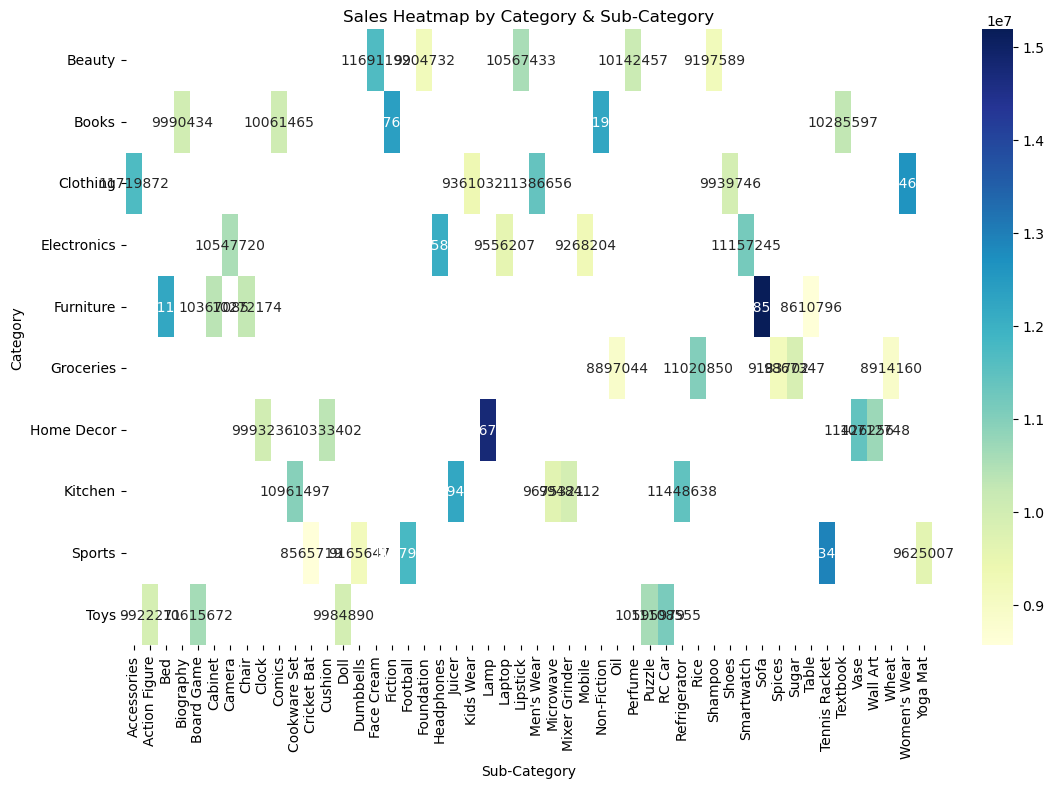

In [42]:
plt.figure(figsize=(13,8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title("Sales Heatmap by Category & Sub-Category")
plt.show()

### Multivariate analysis helps uncover more complex patterns involving three or more variables.

We used pivot tables to analyze:
- Sales distribution across Category and Sub-Category
- Interaction effects between different business dimensions

The heatmap visualization made it easy to identify high-performing and low-performing combinations

## 4.Correlation Analysis
### Correlation matrix

In [43]:
corr = df[['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit', 'Total Amount']].corr()
corr

,Quantity,Unit Price,Discount,Sales,Profit,Total Amount
Quantity,1.000000,-0.010982,-0.007955,0.588705,0.502701,0.594021
Unit Price,-0.010982,1.000000,0.000475,0.715123,0.606293,0.720255
Discount,-0.007955,0.000475,1.000000,-0.101611,-0.088516,-0.003449
Sales,0.588705,0.715123,-0.101611,1.000000,0.848792,0.992080
Profit,0.502701,0.606293,-0.088516,0.848792,1.000000,0.842497
Total Amount,0.594021,0.720255,-0.003449,0.992080,0.842497,1.000000


### Heatmap for correlation

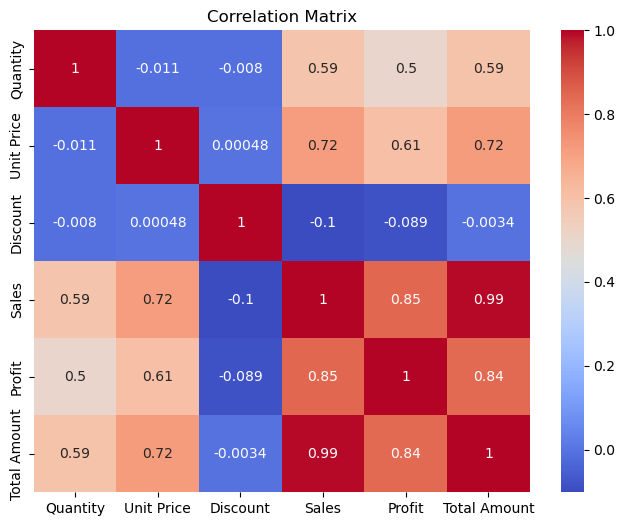

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### 📊 Correlation Analysis
Correlation analysis was performed to understand how numerical variables relate to each other.

A correlation matrix and heatmap revealed:
- Strong or weak relationships between quantities, pricing, sales, and profit
- Whether high sales always result in high profit
- Potential negative impacts of discount on revenue

This step is important for identifying key drivers of business performance.

## 5.Time-Series Analysis(Using order date)
### Monthly Sales Trend

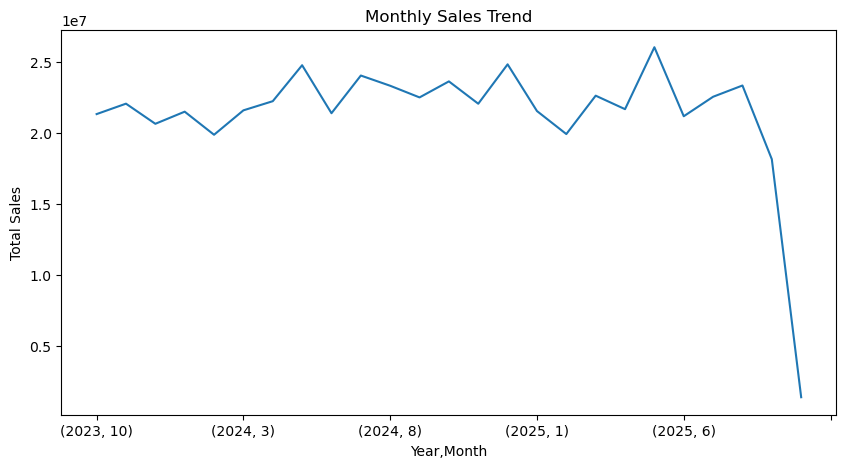

In [45]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

### 🕒 Time-Series Analysis
Using the 'Order Date' column, we created Month and Year variables to analyze sales trends over time.

By plotting monthly sales:
- We identified seasonal peaks or dips
- Observed how sales changed year by year
- Detected growth patterns in the business

This analysis is essential for forecasting and planning.

# Visualizations

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")   # nice default style
plt.rcParams['figure.figsize']=(10,5)

## 1.Bar Plot
Shows which categories bring the most revenue

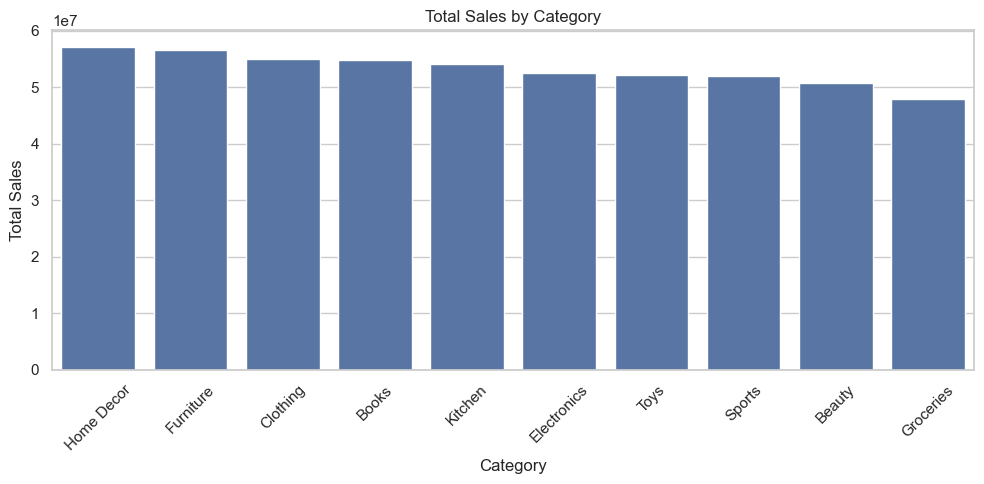

In [51]:
# total sales by category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=cat_sales.index, y=cat_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart above shows total revenue per product category.We can identify top revenue-generating categories and compare them visually

## 2.Line chart/Time series-Monthly sales trend
visualize how sales change month-to-month(across years)

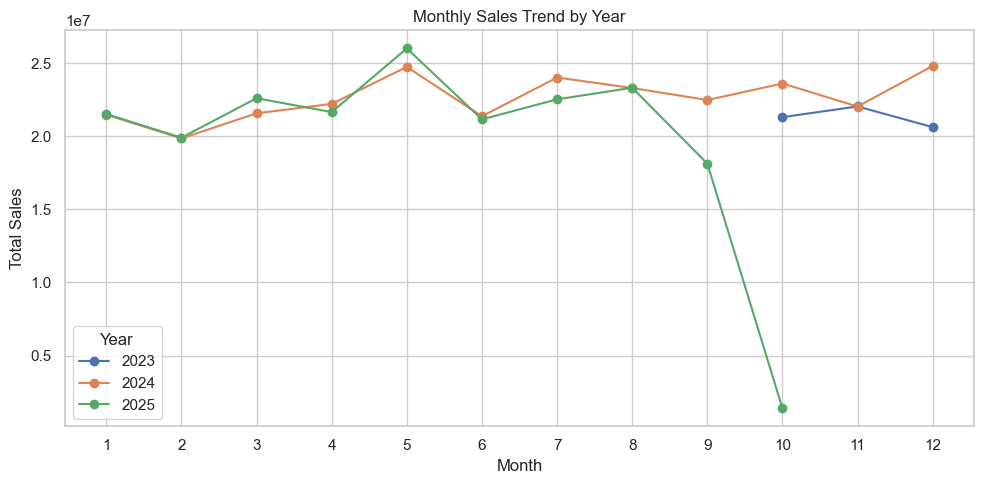

In [52]:
# ensure Month column is numeric (1..12) or month name if you prefer
monthly = df.groupby(['Year','Month'])['Sales'].sum().unstack(level=0)  # columns = years

monthly.plot(marker='o')
plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(ticks=range(1,13), labels=[str(i) for i in range(1,13)])  # if Month is numeric
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

The line chart shows seasonal patterns and year-over-year changes. Look for peak months and growth/decline between years.

## 3.Pie Chart-Category share of total sales

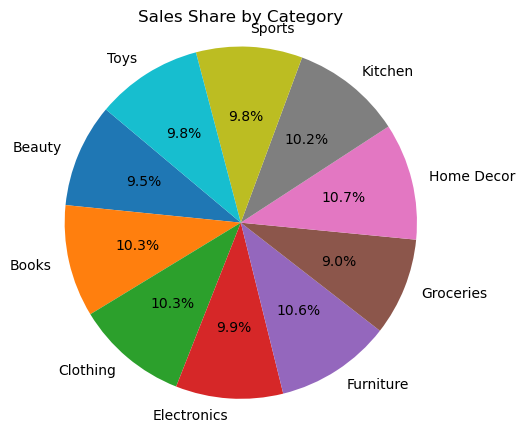

In [11]:
category_share = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(5,5))
plt.pie(category_share, labels=category_share.index, autopct='%1.1f%%', startangle=140)
plt.title("Sales Share by Category")
plt.axis('equal')
plt.show()

The pie chart displays the percentage contribution of each category to overall sales.

## 4.Histogram-Distribution of sales/profit

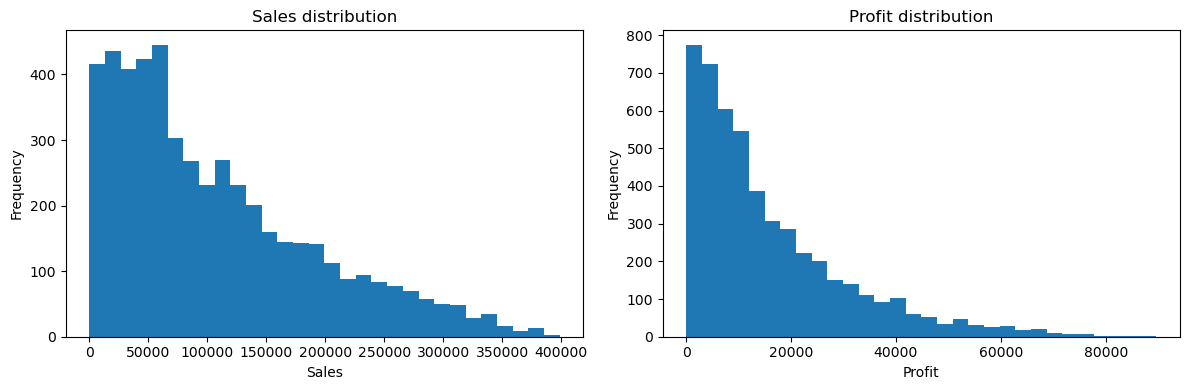

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df['Sales'].dropna(), bins=30)
plt.title("Sales distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df['Profit'].dropna(), bins=30)
plt.title("Profit distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The histograms show distribution shape; skewness indicates many small transactions and a long tail of large transactions.

## 5.Box plot-Sales by category(shows median,spread,outliers)

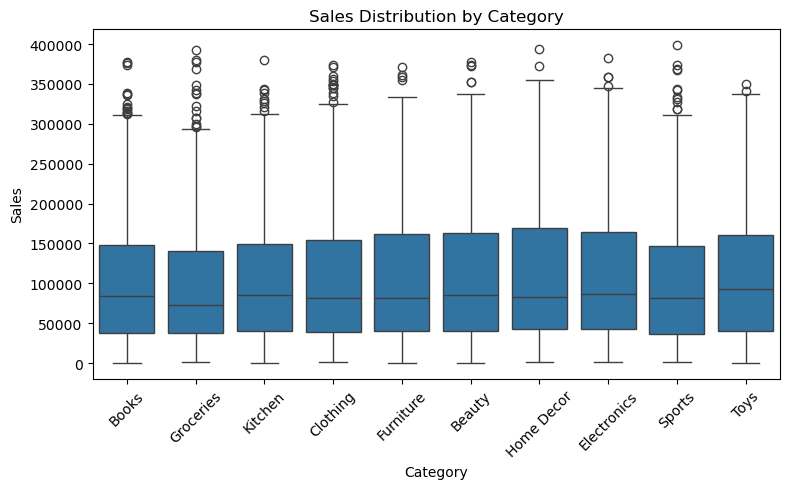

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Box plots highlight medians, interquartile ranges, and outliers by category — useful for spotting categories with highly variable order values.

## 6.Scatterplot-sales vs profit

shows correlation and outliers

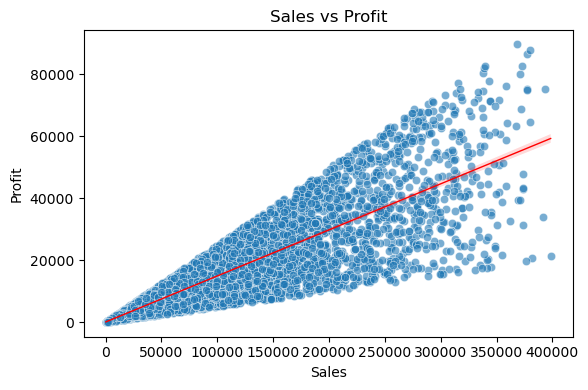

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.6)
sns.regplot(x='Sales', y='Profit', data=df, scatter=False, color='red', line_kws={'linewidth':1})
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

The scatter plot shows whether higher sales correlate with higher profit. The fitted line helps understand the trend; outliers might be returns/discounts or data issues.

## 7.Heatmap-correlation matrix

**Quickly evaluate numeric relationships**

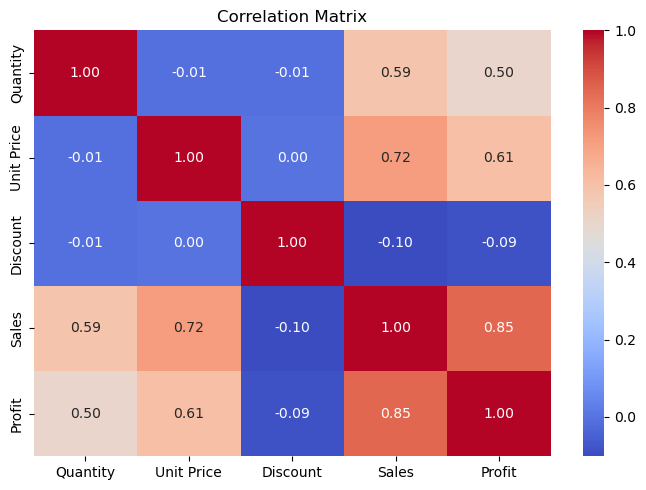

In [4]:
num_cols = ['Quantity','Unit Price','Discount','Sales','Profit']
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 8.Pivot table visualization-Sales by Category * sub category(Heat map)

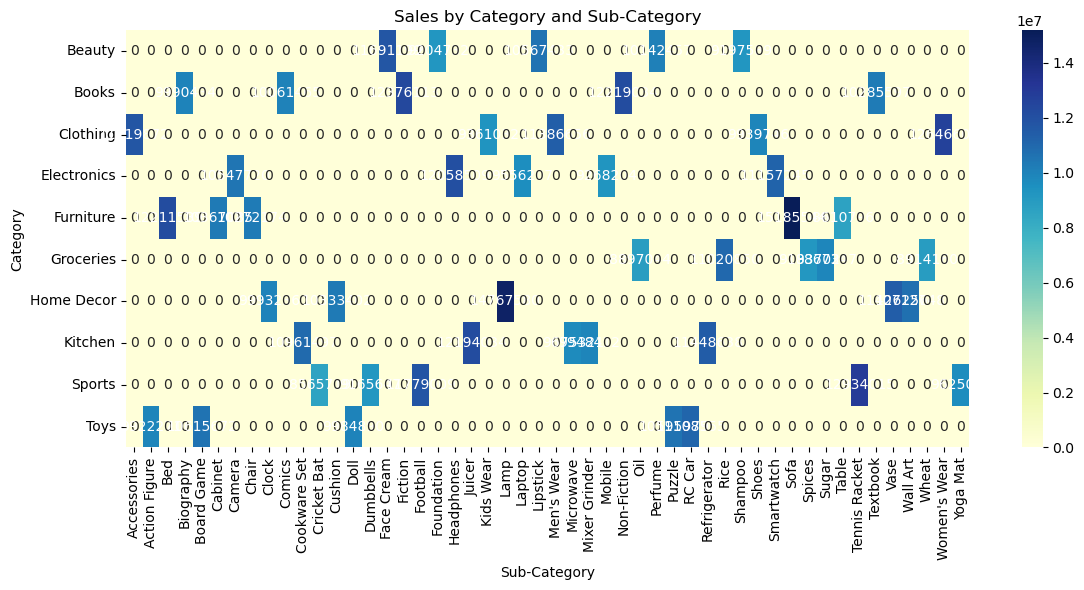

In [5]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Sub-Category', aggfunc='sum', fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title("Sales by Category and Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

The pivot heatmap highlights strong sub-category performers within each category.

## 9.Payment Mode / City analysis — Count plots or stacked bars
### Example: Payment Mode share and Sales by City (top 10).

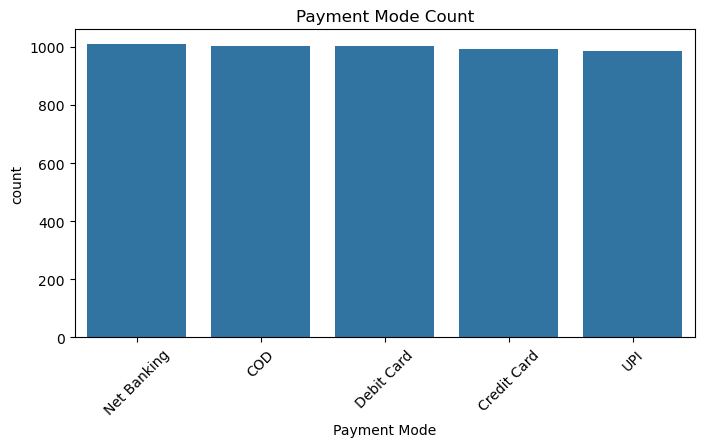

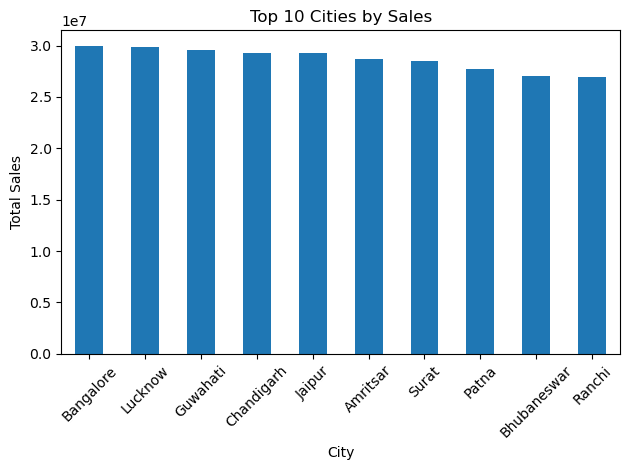

In [6]:
# Payment mode counts
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Payment Mode', order=df['Payment Mode'].value_counts().index)
plt.title("Payment Mode Count")
plt.xticks(rotation=45)
plt.show()

# Top 10 cities by sales
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Sales")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Payment mode shows customer preference (card, netbanking, UPI). City bar chart reveals geographical hotspots.

## 10. Subplots-All main visuals compactly
### Example layout to include several plots on one figure

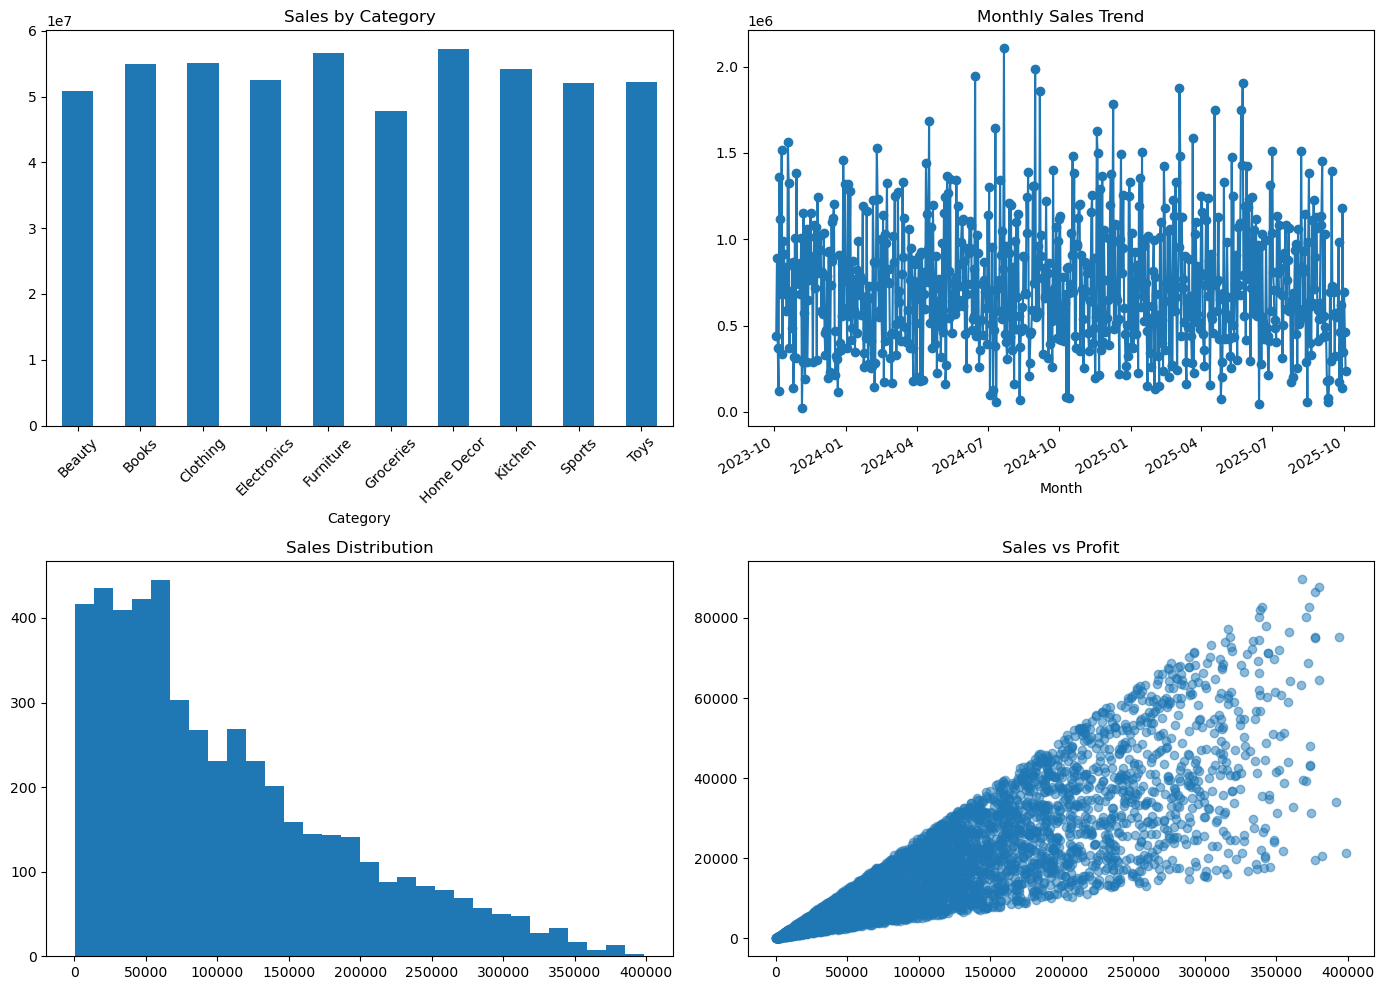

In [12]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
cat_sales = df.groupby('Category')['Sales'].sum()

# (1) Category sales bar
cat_sales.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Sales by Category")
axes[0,0].tick_params(axis='x', rotation=45)

# (2) Monthly sales trend (sum across years)
df.groupby('Order Date')['Sales'].sum().sort_index().plot(ax=axes[0,1], marker='o')
axes[0,1].set_title("Monthly Sales Trend")
axes[0,1].set_xlabel("Month")

# (3) Sales distribution histogram
axes[1,0].hist(df['Sales'].dropna(), bins=30)
axes[1,0].set_title("Sales Distribution")

# (4) Sales vs Profit scatter
axes[1,1].scatter(df['Sales'], df['Profit'], alpha=0.5)
axes[1,1].set_title("Sales vs Profit")

plt.tight_layout()
plt.show()

Use subplots to present a compact dashboard of key insights.

#  Insight Generation and Report

### This section summarizes the most important findings from the exploratory data analysis (EDA). Each insight is derived from the visualizations, summary statistics, and patterns observed in the dataset.

### ***Key insights from the analysis***

**1. Sales are not evenly distributed across categories**

The bar charts and pie charts show that certain product categories contribute a disproportionately high share of overall sales. This suggests that the business relies heavily on a small set of top-performing categories

**2. Seasonal patterns strongly influence monthly sales**

The line chart of monthly sales reveals clear peaks and dips across the year. Some months consistently show higher sales, possibly due to festivals, holidays, or promotional events.

**3. Sales and profit have a moderate positive relationship**

The scatter plot of Sales vs Profit indicates that higher sales generally lead to higher profit, but the relationship is not perfectly linear. There are transactions with high sales but low profit (due to discounting) and low sales but high profit (premium items).

**4. The distribution of Sales and Profit is right-skewed**

Histograms show that most transactions involve smaller sales amounts, with a long tail of high-value transactions.

**5. Discounts negatively affect profit margins**

From the correlation heatmap:

   *  Discount has a negative correlation with Profit

   *  Discount has weak or no correlation with Sales

This means discounts do not necessarily increase sales volume but do reduce profit.

**6. The highest sales occur in specific regions or segments (if used)**

If you plotted sales by region or customer segment, you will have noticed clear differences across segments.

**7. Profitability varies significantly by category**

Some categories may generate high sales but low profit due to operational costs or heavy discounting.

# 📌 Summary of Findings


### The analysis revealed meaningful patterns about sales performance, customer behavior, and business efficiency
   *   The business depends heavily on top-performing product categories.

   *   Clear seasonal spikes show predictable demand cycles.

   *   Discounts harm profit more than they drive sales.

   *   Profitability varies significantly across categories and products.

   *   A small number of high-value transactions drive most revenue.

   *  Sales and profit are positively correlated but influenced by discounting.

### These insights help the company make data-driven decisions to:

   *  Optimize inventory during seasonal peaks

   *  Revise discounting strategies

   *   Strengthen high-performing product lines

   *   Identify high-value customer segments

   *   Improve overall profitability



## Recommendations / Next Steps

  1.**Reduce unnecessary discounts** to protect margins.

  2.**Increase stock and promotions** in high-demand months.

  3.**Focus marketing** on top-selling and high-profit categories.

  4.**Target high-value customers** with loyalty and retention programs.

  5.**Investigate low-profit categories** to determine if pricing, cost, or demand is the issue.